# Sentiment — baselines on dev

**Task.** Binary, `Neutral` vs `Negative`. There is no Positive class; that was a
deliberate labeling choice, not a gap. Negative is what routes a ticket to a
human instead of an AI-drafted reply, so Negative recall is the thing with
operational value.

**Headline metric is `negative_f1`, never accuracy.** ~95.5% of dev tickets are
Neutral, so accuracy is dominated by a class nobody needs predicted. The first
result below makes that concrete.

Everything here evaluates on **dev**. Test stays sealed until a model is chosen.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "ml" / "swiftbench").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "ml"))

import pandas as pd
import matplotlib.pyplot as plt

import swiftbench as sb

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Stamped into every result file so three people's runs stay attributable.
AUTHOR = ""

manifest = sb.splits.ensure()
print("split sha:", manifest["sha"], manifest["counts"])

split sha: e7b5934392cd {'train': 8500, 'dev': 1498, 'test': 3079}


## 1. The floor: always answer "Neutral"

No model. This is the number any real classifier has to be read against.

In [2]:
floor_rows = []
for lang in sb.config.LANGUAGES:
    tr = sb.splits.get([lang], "train")
    dv = sb.splits.get([lang], "dev")
    s = sb.baselines.majority(tr, dv, "sentiment")
    sb.results.save("sentiment", "majority", [lang], lang, "none", "dev", s, author=AUTHOR)
    floor_rows.append({"language": lang, "model": "majority", "arm": "none",
                       **{k: v for k, v in s.items() if not k.startswith("_")}})
    print(f"{lang:9s} predicts '{s['constant_label']}' for everything  ->  "
          f"accuracy {s['accuracy']:.4f}   negative_f1 {s['negative_f1']:.4f}")

floor_df = pd.DataFrame(floor_rows)
print("\n95%+ accuracy, 0.0 negative F1. This is why accuracy is not reported.")

english   predicts 'Neutral' for everything  ->  accuracy 0.9546   negative_f1 0.0000
sinhala   predicts 'Neutral' for everything  ->  accuracy 0.9546   negative_f1 0.0000
singlish  predicts 'Neutral' for everything  ->  accuracy 0.9546   negative_f1 0.0000
tamil     predicts 'Neutral' for everything  ->  accuracy 0.9546   negative_f1 0.0000


tamilish  predicts 'Neutral' for everything  ->  accuracy 0.9546   negative_f1 0.0000

95%+ accuracy, 0.0 negative F1. This is why accuracy is not reported.


## 2. TF-IDF × class-balancing arms

Three arms, run for both linear models across all five languages:

| arm | what it does |
|---|---|
| `none` | train as-is on the 95/5 imbalance |
| `class_weight` | `class_weight="balanced"` — reweights the loss |
| `ros` | random oversampling of Negative up to parity, training rows only |

**No SMOTE arm, ever.** Three papers in `research/` find plain oversampling
matches or beats it on code-mixed low-resource text, and interpolating between
the TF-IDF vectors of two unrelated tickets does not produce a sentence anyone
would write.

30 fits — takes a few minutes. Progress prints per run.

In [3]:
sweep_df = sb.train_classical.sweep("sentiment", author=AUTHOR)

sentiment tfidf-logreg  arm=none         train=english              eval=english   (dev) negative_f1=0.2078 acc=0.9593


sentiment tfidf-logreg  arm=class_weight train=english              eval=english   (dev) negative_f1=0.5699 acc=0.9466


sentiment tfidf-logreg  arm=ros          train=english              eval=english   (dev) negative_f1=0.5698 acc=0.9506


sentiment tfidf-svm     arm=none         train=english              eval=english   (dev) negative_f1=0.4444 acc=0.9633


sentiment tfidf-svm     arm=class_weight train=english              eval=english   (dev) negative_f1=0.6015 acc=0.9646


...

sentiment tfidf-logreg  arm=class_weight train=tamilish             eval=tamilish  (dev) negative_f1=0.5435 acc=0.9439


sentiment tfidf-logreg  arm=ros          train=tamilish             eval=tamilish  (dev) negative_f1=0.5341 acc=0.9453


sentiment tfidf-svm     arm=none         train=tamilish             eval=tamilish  (dev) negative_f1=0.4854 acc=0.9646


sentiment tfidf-svm     arm=class_weight train=tamilish             eval=tamilish  (dev) negative_f1=0.5735 acc=0.9613


sentiment tfidf-svm     arm=ros          train=tamilish             eval=tamilish  (dev) negative_f1=0.4959 acc=0.9593


## 3. Results

`negative_f1` by language and arm. Read the columns left to right — the arm
matters far more than the choice of linear model.

In [4]:
results_df = pd.concat([floor_df, sweep_df], ignore_index=True)
results_df.to_csv(REPO / "ml" / "reports" / "sentiment_baselines_dev.csv", index=False)

pivot = sweep_df.pivot_table(index=["language"], columns=["model", "arm"],
                             values="negative_f1").round(4)
display(pivot)

print("\nBest arm per language:")
best = sweep_df.loc[sweep_df.groupby("language")["negative_f1"].idxmax()]
display(best[["language", "model", "arm", "negative_f1", "negative_precision",
              "negative_recall", "accuracy"]].round(4))

model    tfidf-logreg                    tfidf-svm                
arm      class_weight    none     ros class_weight    none     ros
language                                                          
english        0.5699  0.2078  0.5698       0.6015  0.4444  0.5439
singlish       0.6054  0.2716  0.6395       0.5839  0.5225  0.5954
sinhala        0.5833  0.2278  0.6163       0.5839  0.4762  0.5522
tamil          0.5622  0.2222  0.5896       0.5972  0.4808  0.5414
tamilish       0.5435  0.2278  0.5341       0.5735  0.4854  0.4959


Best arm per language:


,language,model,arm,negative_f1,negative_precision,negative_recall,accuracy
4,english,tfidf-svm,class_weight,0.6015,0.6154,0.5882,0.9646
14,singlish,tfidf-logreg,ros,0.6395,0.5288,0.8088,0.9586
8,sinhala,tfidf-logreg,ros,0.6163,0.5096,0.7794,0.9559
22,tamil,tfidf-svm,class_weight,0.5972,0.5658,0.6324,0.9613
28,tamilish,tfidf-svm,class_weight,0.5735,0.5735,0.5735,0.9613


### The accuracy trap, plotted

The arm with the **highest accuracy** is the **worst model**. Left panel ranks by
accuracy, right panel by Negative F1 — the order reverses.

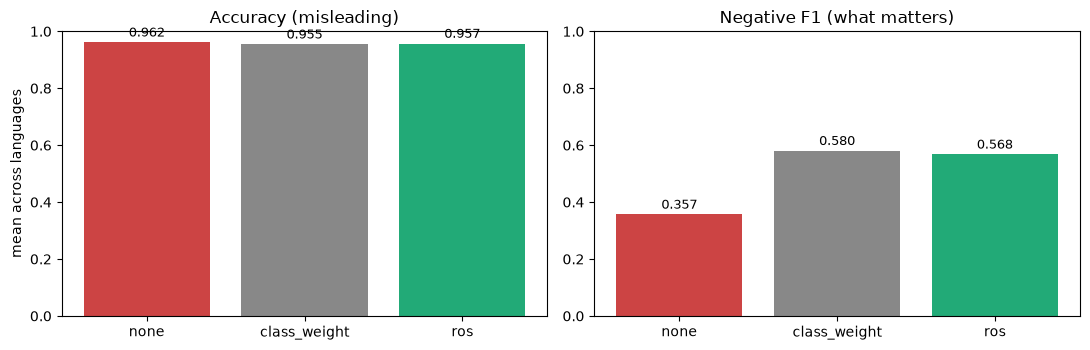

In [5]:
agg = sweep_df.groupby("arm")[["accuracy", "negative_f1"]].mean().reindex(sb.imbalance.ARMS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, metric, title in zip(axes, ["accuracy", "negative_f1"],
                             ["Accuracy (misleading)", "Negative F1 (what matters)"]):
    ax.bar(agg.index, agg[metric], color=["#c44", "#888", "#2a7"])
    ax.set_title(title)
    ax.set_ylim(0, 1)
    for i, v in enumerate(agg[metric]):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
axes[0].set_ylabel("mean across languages")
plt.tight_layout()
plt.show()

## 4. Where the best model still fails

Confusion matrix and a sample of missed Negative tickets — the ones that would
have been auto-replied to instead of escalated.

In [6]:
top = best.sort_values("negative_f1", ascending=False).iloc[0]
print(f"inspecting: {top.model} / arm={top.arm} / {top.language}\n")

fit = sb.train_classical.run("sentiment", top.model, [top.language], top.language,
                             arm=top.arm, save=False, verbose=False)
dv = sb.splits.get([top.language], "dev")
labels, cm = sb.metrics.confusion(dv.sentiment, fit["_predictions"], "sentiment")
display(pd.DataFrame(cm, index=[f"true {l}" for l in labels],
                     columns=[f"pred {l}" for l in labels]))

missed = dv[(dv.sentiment == "Negative") & (fit["_predictions"] == "Neutral")]
print(f"\n{len(missed)} Negative tickets missed. Sample:")
for _, r in missed.head(6).iterrows():
    print(f"  [{r.category}] {r.text_en[:90]}")

inspecting: tfidf-logreg / arm=ros / singlish



,pred Neutral,pred Negative
true Neutral,1381,49
true Negative,13,55



13 Negative tickets missed. Sample:
  [card_payment_wrong_exchange_rate] Why on earth is the exchange rate so bad?   Can I get a rate closer to the actual interban
  [pending_top_up] Is there something wrong with my top up I did an hour ago? it's still pending. I need that
  [top_up_reverted] Why isn't top-up working? My top-up money disappeared after I saw that it was successfully
  [balance_not_updated_after_cheque_or_cash_deposit] After trying to update my account balance yesterday by cheque it doesn't seem to working. 
  [balance_not_updated_after_cheque_or_cash_deposit] What is going on? My balance still hasn't updated and it has been two weeks since I deposi
  [direct_debit_payment_not_recognised] Recently, a few weeks ago there was a transaction made on my account by some seller that I


## 5. Read-out

Fill this in after a run, then move on to an encoder arm:

- Floor (always-Neutral): accuracy ~0.955, negative_f1 **0.000**
- Best classical arm: see table above
- Open question: does an encoder (XLM-R / mmBERT) beat TF-IDF+ROS on
  `negative_f1`, or is 462 Negative training tickets simply too few for
  fine-tuning to help?

Test set is still sealed. Only evaluate the single chosen model on it, once.